# **1. БИЗНЕС-АНАЛИЗ: ОПИСАНИЕ КЕЙСА**

Анализ онлайн-рынка персональных компьютеров.

К нам обратился клиент, который занимается сборкой и продажей персональных компьютеров (за исключением мини-ПК и моноблоков). В связи с ростом популярности интернет-магазинов, таких как Wildberries, Ozon, OnlineTrade и т.п., за последние несколько лет, а также с целью привлечения большего числа клиентов при одновременном снижении затрат на содержание собственного магазина, доставку и рекламу товаров на 10% он планирует выйти на онлайн-рынок в ближайшие 3 месяца. В связи с этим клиент хотел бы узнать, от чего зависит цена, а также популярность персональных компьютеров, выкладываемых на онлайн-площадках, чтобы в дальнейшем планировать к сборке востребованные по техническим характеристикам компьютеры и продавать их по конкурентной цене.
Специалистом по сбору данных были выгружены датасеты с одного из популярных онлайн-магазинов, содержащие информацию о товарах категории «Компьютеры и моноблоки».

Проанализируйте полученные данные и представьте аналитический отчет, содержащий выводы и рекомендации для Заказчика, которые помогут ему для решения его бизнес-задач.

**Наша задача** — Необходимо проанализировать цены конкурентов, а также наиболее популярные комплектующие, продаваемые в составе персональных компьютеров.

Исходные данные:

• идентификатор товара (product_id)

• наименование товара (title)

• цена товара в руб. (price)

• количество продаж (sales)

• количество отзывов (feedbacks)

• наименование продавца (seller)

• рейтинг продавца (seller_rating)

• данные о процессоре (Процессор), в т. ч. о типе процессора (Процессор_тип), о количестве ядер процессора (Количество ядер процессора)

• данные об оперативной памяти (Оперативная память), в т. ч. о типе оперативной памяти (Тип оперативной памяти), об объеме оперативной памяти (Объем оперативной памяти (Гб))

• данные о жестком диске (Жесткий диск), в т. ч. об объеме накопителя HDD (Объем накопителя HDD), об объеме накопителя SSD (Объем накопителя SSD)

• данные о видеопроцессоре (Видеопроцессор)

• данные об операционной системе (Операционная система)

• данные о гарантийном сроке (Гарантийный срок)

• страна производства (Страна производства)

• данные о габарите товара (Габариты товара), в т. ч. о ширине предмета (Ширина предмета), о глубине предмета (Глубина предмета), о высоте предмета (Высота предмета), о весе предмета (Вес без упаковки (кг))

• данные о габарите товара с упаковкой (Габариты товара (с упаковкой)), в т. ч. длине упаковки (Длина упаковки), о ширине упаковки (Ширина упаковки), о высоте упаковки (Высота упаковки), о весе предмета с упаковкой (Вес с упаковкой (кг))

**Формат файла** по результатам предобработки: *csv*

# **2. ИЗУЧЕНИЕ ДАННЫХ**

# Импорт библиотек

In [ ]:
# из библиотеки google.colab импортируем класс files при необходимости подгрузки файла с персонального компьютера
# from google.colab import files
# импортируем pandas - основную библиотеку аналитика данных
import pandas as pd
# импортируем библиотеку numpy для возможных расчетов
import numpy as np
# импортируем модуль json для распаковки структур данных формата json
import json
# импортируем статистические библиотеки
import scipy
import scipy.stats as stats
# импортируем модуль pyplot из библиотеки matplotlib для визуализации
from matplotlib import pyplot as plt
# импортируем библиотеку seaborn для визуализации
import seaborn as sns
# импортируем библиотеку re
import re
# импортируем библиотеку files для работы с файлами
from google.colab import files

import matplotlib.pyplot as plt

In [ ]:
# устанавливаем размер графиков
sns.set(rc={'figure.figsize':(8,4)})

# Подгрузка файла

In [ ]:
# загружаем файл с исходными данными
uploaded = files.upload()

Saving wb_pc_hard.csv to wb_pc_hard.csv


# Чтение файла

In [ ]:
df = pd.read_csv('wb_pc_hard.csv')

# Обзор датасета

In [ ]:
df.head()

,product_id,title,price,sales,feedbacks,seller,seller_rating,Процессор,Оперативная память,Жесткий диск,Видеопроцессор,Операционная система,Гарантийный срок,Страна производства,Габариты товара,Габариты товара (с упаковкой)
0,10148385,Системный блок OFFICE 120 WB 0710623 J1800/4Gb...,10805₽,Купили более 400 раз,7 отзывов,NaN,NaN,"{'Процессор_тип': 'Intel Celeron', 'Количество...","{'Тип оперативной памяти': 'DDR 3', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",Intel HD Graphics,отсутствует,3года,Россия,"{'Ширина предмета': '28.5 см', 'Глубина предме...","{'Длина упаковки': '43.5 см', 'Ширина упаковки..."
1,17877962,Системный блок,32900₽,NaN,0 отзывов,NaN,NaN,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",не заполнено,отсутствует,NaN,Китай,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': '43 см', 'Ширина упаковки':..."
2,17880420,Компьютер Hp Prodesk 400 g6 mt,35720₽,NaN,0 отзывов,NaN,NaN,"{'Процессор_тип': 'не заполнено', 'Количество ...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",не заполнено,отсутствует,NaN,NaN,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': None, 'Ширина упаковки': No..."
3,19347937,Офисный Компьютер Robotcomp Казначей V1,39237₽,Купили более 10 раз,1 отзыв,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",Intel UHD Graphics 630,windows пробная,3 Года (36 месяцев),Россия,"{'Ширина предмета': '28 см', 'Глубина предмета...","{'Длина упаковки': '60 см', 'Ширина упаковки':..."
4,19348951,Игровой Компьютер Robotcomp М16 2.0 V1,76188₽,Купили более 200 раз,94 отзыва,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",NVIDIA GeForce GTX 1660,windows пробная,3 Года (36 месяцев),Россия,"{'Ширина предмета': '20 см', 'Глубина предмета...","{'Длина упаковки': '50 см', 'Ширина упаковки':..."


In [ ]:
df.shape

(4500, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     4500 non-null   int64  
 1   title                          4500 non-null   object 
 2   price                          4499 non-null   object 
 3   sales                          1164 non-null   object 
 4   feedbacks                      4500 non-null   object 
 5   seller                         4391 non-null   object 
 6   seller_rating                  4389 non-null   float64
 7   Процессор                      4500 non-null   object 
 8   Оперативная память             4500 non-null   object 
 9   Жесткий диск                   4500 non-null   object 
 10  Видеопроцессор                 4500 non-null   object 
 11  Операционная система           4500 non-null   object 
 12  Гарантийный срок               2648 non-null   o

# Выявление проблем

1. Наличие признаков, не представляющих ценности в рамках кейса ('Отзывы, шт.', 'Гарантийный срок', 'Габариты товара', 'Габариты товара (с упаковкой)')
2. Возможно наличие дубликатов
3. Приведение названий ячеек к единому языку
3. Наличие незаполненных значений ('price', 'sales', 'Страна производства')
4. Наличие вложенных значений (словарей по признакам 'Процессор',	'Оперативная память',	'Жесткий диск')
5. Приведение признаков в необходимый формат (в int64: 'price', 'sales', 'feedbacks', 'Оперативная память')
6. Возможные другие проблемы, которые могут быть выявлены в процессе предобработки данных

# **3. ПРЕДОБРАБОТКА ДАННЫХ**

# Приводим названия ячеек к единому языку

In [ ]:
df = df.rename(columns={'price': 'Цена, руб.', 'sales': 'Продано, шт.', 'feedbacks': 'Отзывы, шт.', 'seller': 'Продавец', 'seller_rating': 'Рейтинг продавца', 'title': 'Наименование'})
df

,product_id,Наименование,"Цена, руб.","Продано, шт.","Отзывы, шт.",Продавец,Рейтинг продавца,Процессор,Оперативная память,Жесткий диск,Видеопроцессор,Операционная система,Гарантийный срок,Страна производства,Габариты товара,Габариты товара (с упаковкой)
0,10148385,Системный блок OFFICE 120 WB 0710623 J1800/4Gb...,10805₽,Купили более 400 раз,7 отзывов,NaN,NaN,"{'Процессор_тип': 'Intel Celeron', 'Количество...","{'Тип оперативной памяти': 'DDR 3', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",Intel HD Graphics,отсутствует,3года,Россия,"{'Ширина предмета': '28.5 см', 'Глубина предме...","{'Длина упаковки': '43.5 см', 'Ширина упаковки..."
1,17877962,Системный блок,32900₽,NaN,0 отзывов,NaN,NaN,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",не заполнено,отсутствует,NaN,Китай,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': '43 см', 'Ширина упаковки':..."
2,17880420,Компьютер Hp Prodesk 400 g6 mt,35720₽,NaN,0 отзывов,NaN,NaN,"{'Процессор_тип': 'не заполнено', 'Количество ...","{'Тип оперативной памяти': 'не заполнено', 'Об...","{'Объем накопителя HDD': None, 'Объем накопите...",не заполнено,отсутствует,NaN,NaN,"{'Ширина предмета': None, 'Глубина предмета': ...","{'Длина упаковки': None, 'Ширина упаковки': No..."
3,19347937,Офисный Компьютер Robotcomp Казначей V1,39237₽,Купили более 10 раз,1 отзыв,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",Intel UHD Graphics 630,windows пробная,3 Года (36 месяцев),Россия,"{'Ширина предмета': '28 см', 'Глубина предмета...","{'Длина упаковки': '60 см', 'Ширина упаковки':..."
4,19348951,Игровой Компьютер Robotcomp М16 2.0 V1,76188₽,Купили более 200 раз,94 отзыва,Robotcomp,4.7,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': None, 'Объем накопите...",NVIDIA GeForce GTX 1660,windows пробная,3 Года (36 месяцев),Россия,"{'Ширина предмета': '20 см', 'Глубина предмета...","{'Длина упаковки': '50 см', 'Ширина упаковки':..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,152971271,Игровой ПК,70000₽,NaN,0 отзывов,Personal PC,0.0,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': '1000 гб', 'Объем нак...",Nvidia,Windows 10 pro,1 год,NaN,"{'Ширина предмета': '35 см', 'Глубина предмета...","{'Длина упаковки': '40 см', 'Ширина упаковки':..."
4496,152978335,Игровой ПК,70000₽,NaN,0 отзывов,Personal PC,0.0,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': '1000 Гб', 'Объем нак...",NVIDIA,Windows 10 Pro,1 год,NaN,"{'Ширина предмета': '35 см', 'Глубина предмета...","{'Длина упаковки': '40 см', 'Ширина упаковки':..."
4497,152979371,Игровой ПК,70000₽,NaN,0 отзывов,Personal PC,0.0,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': '1000 Гб', 'Объем нак...",NVIDIA,Windows 10 Pro,1 год,NaN,"{'Ширина предмета': '35 см', 'Глубина предмета...","{'Длина упаковки': '40 см', 'Ширина упаковки':..."
4498,152979918,Игровой ПК,70000₽,NaN,0 отзывов,Personal PC,0.0,"{'Процессор_тип': 'Intel Core i5', 'Количество...","{'Тип оперативной памяти': 'DDR 4', 'Объем опе...","{'Объем накопителя HDD': '1000 гб', 'Объем нак...",Nvidia,Windows 10 pro,1 год,NaN,"{'Ширина предмета': '30 см', 'Глубина предмета...","{'Длина упаковки': '40 см', 'Ширина упаковки':..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     4500 non-null   int64  
 1   Наименование                   4500 non-null   object 
 2   Цена, руб.                     4499 non-null   object 
 3   Продано, шт.                   1164 non-null   object 
 4   Отзывы, шт.                    4500 non-null   object 
 5   Продавец                       4391 non-null   object 
 6   Рейтинг продавца               4389 non-null   float64
 7   Процессор                      4500 non-null   object 
 8   Оперативная память             4500 non-null   object 
 9   Жесткий диск                   4500 non-null   object 
 10  Видеопроцессор                 4500 non-null   object 
 11  Операционная система           4500 non-null   object 
 12  Гарантийный срок               2648 non-null   o

# Преобразуем колонки с данными памяти и жесткого диска

In [ ]:
df['Оперативная память'] = df['Оперативная память'].apply(eval)
df['Жесткий диск'] = df['Жесткий диск'].apply(eval)
df['Тип оперативной памяти'] = df['Оперативная память'].apply(lambda x: x.get('Тип оперативной памяти'))
df['Объем оперативной памяти (Гб)'] = df['Оперативная память'].apply(lambda x: x.get('Объем оперативной памяти (Гб)'))

# Создаем новые колонки для жесткого диска
df['Объем накопителя HDD, ГБ'] = df['Жесткий диск'].apply(lambda x: x.get('Объем накопителя HDD'))
df['Объем накопителя SSD, ГБ'] = df['Жесткий диск'].apply(lambda x: x.get('Объем накопителя SSD'))

# оставляем в столбце 'Объем оперативной памяти (Гб)' только цифры
df['Объем оперативной памяти (Гб)'] = df['Объем оперативной памяти (Гб)'].str.replace(r"[^\d\.]", "", regex=True)

# Удаляем исходные колонки
df.drop(['Оперативная память', 'Жесткий диск'], axis=1, inplace=True)


# Преобразуем колонку с наименованием процессоров

In [ ]:
# Преобразуем строки в словари
df['Процессор'] = df['Процессор'].apply(eval)

# Создаем новые колонки из словаря
df['Процессор_тип'] = df['Процессор'].apply(lambda x: x.get('Процессор_тип'))
df['Количество ядер процессора'] = df['Процессор'].apply(lambda x: x.get('Количество ядер процессора'))

# Удаляем исходную колонку с процессом
df.drop('Процессор', axis=1, inplace=True)

# Преобразуем колонку с ценой

In [ ]:
df['Цена, руб.'] = df['Цена, руб.'].str[:-1]

# Оставляем в столбце 'Продано, шт.' только количество продаж

In [ ]:
df['Продано, шт.'] = df['Продано, шт.'].str.replace(r"[^\d\.]", "", regex=True)


# Удаляем столбцы с отзывами, гарантийными сроками и габаритами товаров, т.к. в рамках кейса они не представляют интереса

In [ ]:
df = df.drop(columns=['Гарантийный срок', 'Габариты товара', 'Габариты товара (с упаковкой)', 'Отзывы, шт.'])

# Переводим все объемы накопителей в ГБ, чтобы затем перевести их в числа

In [ ]:
# Регулярное выражение для поиска числа и последующих символов "ТБ", "тб", "tb", "Tb"
pattern = r'(\d+(?:\.\d+)?)([Тt][Бb])'

# Функция для обработки значений
def convert_to_gb(capacity):
    # Исключение: если нет совпадающего шаблона, вернуть оригинал
    if not isinstance(capacity, str) or not re.search(pattern, capacity):
        return capacity

    # Ищем совпадение
    match = re.search(pattern, capacity)
    if match:
        # Первое групповое выделение — число, второе — единица измерения
        number = int(match.group(1))
        return f"{number * 1024:.2f} ГБ"
    else:
        return capacity

# Применяем функцию к столбцу
df['Объем накопителя HDD, ГБ'] = df['Объем накопителя HDD, ГБ'].apply(convert_to_gb)
df['Объем накопителя SSD, ГБ'] = df['Объем накопителя SSD, ГБ'].apply(convert_to_gb)
df['Объем оперативной памяти (Гб)'] = df['Объем оперативной памяти (Гб)'].apply(convert_to_gb)

# оставляем в столбце 'Объем накопителя HDD' только цифры
df['Объем накопителя HDD, ГБ'] = df['Объем накопителя HDD, ГБ'].str.replace(r"[^\d\.]", "", regex=True)

# оставляем в столбце 'Объем накопителя SSD' только цифры
df['Объем накопителя SSD, ГБ'] = df['Объем накопителя SSD, ГБ'].str.replace(r"[^\d\.]", "", regex=True)

# оставляем в столбце 'Объем оперативной памяти (Гб)' только цифры
df['Объем оперативной памяти (Гб)'] = df['Объем оперативной памяти (Гб)'].str.replace(r"[^\d\.]", "", regex=True)


# Устанавливаем тип столбцов

In [ ]:
df['Цена, руб.'] = pd.to_numeric(df['Цена, руб.'], errors='coerce').fillna(0).astype(int)
df['Продано, шт.'] = pd.to_numeric(df['Продано, шт.'], errors='coerce').fillna(0).astype(int)
df['Объем оперативной памяти (Гб)'] = pd.to_numeric(df['Объем оперативной памяти (Гб)'], errors='coerce').fillna(0).astype(int)
df['Объем накопителя HDD, ГБ'] = pd.to_numeric(df['Объем накопителя HDD, ГБ'], errors='coerce').fillna(0).astype(int)
df['Объем накопителя SSD, ГБ'] = pd.to_numeric(df['Объем накопителя SSD, ГБ'], errors='coerce').fillna(0).astype(int)
df['Количество ядер процессора'] = pd.to_numeric(df['Количество ядер процессора'], errors='coerce').fillna(0).astype(int)



In [ ]:
# Все столбцы, состоящие из строк (Наименование, Продавец, Видеопроцессор, Операционная система, Страна производства,
# Тип оперативной памяти, Процессор_тип) переводим в нижний регистр, первую букву делаем заглавной
df = df.applymap(lambda x: x.capitalize() if isinstance(x, str) else x)

/tmp/ipython-input-907464264.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.capitalize() if isinstance(x, str) else x)


In [ ]:
df

,product_id,Наименование,"Цена, руб.","Продано, шт.",Продавец,Рейтинг продавца,Видеопроцессор,Операционная система,Страна производства,Тип оперативной памяти,Объем оперативной памяти (Гб),"Объем накопителя HDD, ГБ","Объем накопителя SSD, ГБ",Процессор_тип,Количество ядер процессора
0,10148385,Системный блок office 120 wb 0710623 j1800/4gb...,10805,400,NaN,NaN,Intel hd graphics,Отсутствует,Россия,Ddr 3,4,0,0,Intel celeron,2
1,17877962,Системный блок,32900,0,NaN,NaN,Не заполнено,Отсутствует,Китай,Не заполнено,16,0,256,Intel core i5,0
2,17880420,Компьютер hp prodesk 400 g6 mt,35720,0,NaN,NaN,Не заполнено,Отсутствует,NaN,Не заполнено,16,0,512,Не заполнено,0
3,19347937,Офисный компьютер robotcomp казначей v1,39237,10,Robotcomp,4.7,Intel uhd graphics 630,Windows пробная,Россия,Ddr 4,8,0,480,Intel core i5,6
4,19348951,Игровой компьютер robotcomp м16 2.0 v1,76188,200,Robotcomp,4.7,Nvidia geforce gtx 1660,Windows пробная,Россия,Ddr 4,16,0,960,Intel core i5,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,152971271,Игровой пк,70000,0,Personal pc,0.0,Nvidia,Windows 10 pro,NaN,Ddr 4,16,1000,500,Intel core i5,6
4496,152978335,Игровой пк,70000,0,Personal pc,0.0,Nvidia,Windows 10 pro,NaN,Ddr 4,16,1000,500,Intel core i5,6
4497,152979371,Игровой пк,70000,0,Personal pc,0.0,Nvidia,Windows 10 pro,NaN,Ddr 4,16,1000,500,Intel core i5,6
4498,152979918,Игровой пк,70000,0,Personal pc,0.0,Nvidia,Windows 10 pro,NaN,Ddr 4,16,1000,500,Intel core i5,6


In [ ]:
# оставим в датафрейме только позиции, которые по стоимости более 5000 руб., т.к. те, которые меньше точно не являются ПК
df = df[df['Цена, руб.'] > 5000]

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4323 entries, 0 to 4499
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     4323 non-null   int64  
 1   Наименование                   4323 non-null   object 
 2   Цена, руб.                     4323 non-null   int64  
 3   Продано, шт.                   4323 non-null   int64  
 4   Продавец                       4214 non-null   object 
 5   Рейтинг продавца               4212 non-null   float64
 6   Видеопроцессор                 4323 non-null   object 
 7   Операционная система           4323 non-null   object 
 8   Страна производства            2484 non-null   object 
 9   Тип оперативной памяти         4323 non-null   object 
 10  Объем оперативной памяти (Гб)  4323 non-null   int64  
 11  Объем накопителя HDD, ГБ       4323 non-null   int64  
 12  Объем накопителя SSD, ГБ       4323 non-null   int64 

# Проверка и исключение дубликатов

In [ ]:
df.columns
df.duplicated().sum()

np.int64(467)

In [ ]:
# исключение дубликатов по всем признакам датафрейма
df.drop_duplicates(inplace=True)

/tmp/ipython-input-965936528.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


In [ ]:
# контроль размеров датафрейма
df.shape

(3856, 15)

In [ ]:
df

,product_id,Наименование,"Цена, руб.","Продано, шт.",Продавец,Рейтинг продавца,Видеопроцессор,Операционная система,Страна производства,Тип оперативной памяти,Объем оперативной памяти (Гб),"Объем накопителя HDD, ГБ","Объем накопителя SSD, ГБ",Процессор_тип,Количество ядер процессора
0,10148385,Системный блок office 120 wb 0710623 j1800/4gb...,10805,400,NaN,NaN,Intel hd graphics,Отсутствует,Россия,Ddr 3,4,0,0,Intel celeron,2
1,17877962,Системный блок,32900,0,NaN,NaN,Не заполнено,Отсутствует,Китай,Не заполнено,16,0,256,Intel core i5,0
2,17880420,Компьютер hp prodesk 400 g6 mt,35720,0,NaN,NaN,Не заполнено,Отсутствует,NaN,Не заполнено,16,0,512,Не заполнено,0
3,19347937,Офисный компьютер robotcomp казначей v1,39237,10,Robotcomp,4.7,Intel uhd graphics 630,Windows пробная,Россия,Ddr 4,8,0,480,Intel core i5,6
4,19348951,Игровой компьютер robotcomp м16 2.0 v1,76188,200,Robotcomp,4.7,Nvidia geforce gtx 1660,Windows пробная,Россия,Ddr 4,16,0,960,Intel core i5,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,152971271,Игровой пк,70000,0,Personal pc,0.0,Nvidia,Windows 10 pro,NaN,Ddr 4,16,1000,500,Intel core i5,6
4496,152978335,Игровой пк,70000,0,Personal pc,0.0,Nvidia,Windows 10 pro,NaN,Ddr 4,16,1000,500,Intel core i5,6
4497,152979371,Игровой пк,70000,0,Personal pc,0.0,Nvidia,Windows 10 pro,NaN,Ddr 4,16,1000,500,Intel core i5,6
4498,152979918,Игровой пк,70000,0,Personal pc,0.0,Nvidia,Windows 10 pro,NaN,Ddr 4,16,1000,500,Intel core i5,6


# Обработка пропущенных значений

In [ ]:
df.isna().sum()

,0
product_id,0
Наименование,0
"Цена, руб.",0
"Продано, шт.",0
Продавец,96
Рейтинг продавца,97
Видеопроцессор,0
Операционная система,0
Страна производства,1643
Тип оперативной памяти,0


**Обзор пропущенных значений** по признакам:
1. 'Страна производства', 'Продавец' и 'Рейтинг продавца' - пользователи указывают эти данные по желанию (по кейсу нет необходимости в исключении пропущенных значений)

In [ ]:
# перезапишем индексный столбец
df.reset_index(drop=True, inplace=True)

Выводы по разделу:
1. Был представлен датасет с данными онлайн-магазина Заказчика: файл в формате csv, содержащий 4500 строк (объектов) и 16 столбцов (признаков).
2. В ходе очистки данных были исключены:
* признаки, не представляющие ценности в рамках указанных условий;
* "полные" дубликаты (ошибочно задвоенные записи);
3. Значения признаков были преобразованы в соответствующие форматы, необходимые для последующего анализа.
8. По итогу преобразований получен файл в формате csv, содержащий 3856 строк (объектов) и 15 столбцов (признаков).

# **4. АНАЛИЗ ДАННЫХ**

# Этапы анализа:

1. Определить типы переменных.
2. Проанализировать каждый признак отдельно.
3. Проанализировать взаимосвязи признаков.
4. Проинтерпретировать результаты.

# Типы переменных:

1. Категориальные:

      Наименование,
      Продавец,
      Видеопроцессор,
      Операционная система,
      Страна производства,
      Тип оперативной памяти,
      Процессор_тип
2. Количественные (Дискретные):

      Цена, руб.,
      Продано, шт.,
      Объем оперативной памяти (Гб),
      Объем накопителя HDD, ГБ,
      Объем накопителя SSD, ГБ,
      Количество ядер процессора

3. Порядковые: Рейтинг продавца


# 4.1 Количественные признаки

# Цена, руб.

In [ ]:
max_value = df['Цена, руб.'].max()
min_value = df['Цена, руб.'].min()
mean_value = df['Цена, руб.'].mean()
median_value = df['Цена, руб.'].median()
print(f'Наибольшая цена: {max_value}', f'Наименьшая цена: {min_value}',
     f'Средняя цена: {mean_value}', f'Медианное значение цены: {median_value}', sep='\n')

Наибольшая цена: 235900
Наименьшая цена: 5040
Средняя цена: 64823.785010373445
Медианное значение цены: 64881.0


In [ ]:
percentile_10_value = df['Цена, руб.'].quantile(0.10)
percentile_25_value = df['Цена, руб.'].quantile(0.25)
percentile_50_value = df['Цена, руб.'].quantile(0.50)
percentile_75_value = df['Цена, руб.'].quantile(0.75)
percentile_90_value = df['Цена, руб.'].quantile(0.90)
print(f'10-й процентиль: {percentile_10_value}',
      f'25-й процентиль: {percentile_25_value}',
      f'50-й процентиль: {percentile_50_value}',
      f'75-й процентиль: {percentile_75_value}',
      f'90-й процентиль: {percentile_90_value}', sep='\n')

10-й процентиль: 26008.0
25-й процентиль: 37660.25
50-й процентиль: 64881.0
75-й процентиль: 82460.0
90-й процентиль: 104293.5


In [ ]:
#df['Цена, руб.'].describe()

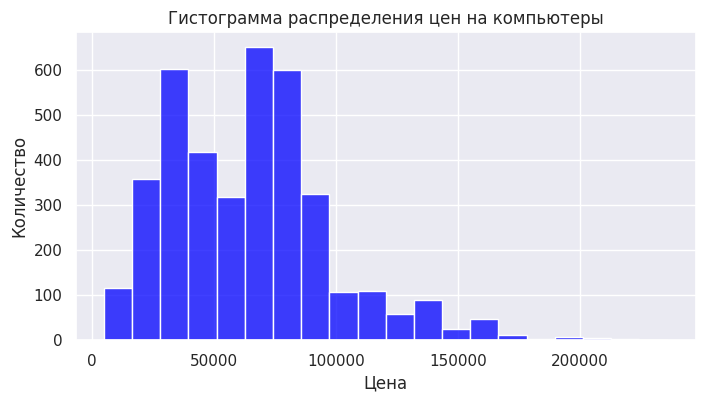

In [ ]:
sns.histplot(df['Цена, руб.'], bins=20, color='blue')
plt.title('Гистограмма распределения цен на компьютеры')
plt.xlabel('Цена')
plt.ylabel('Количество')
plt.show()

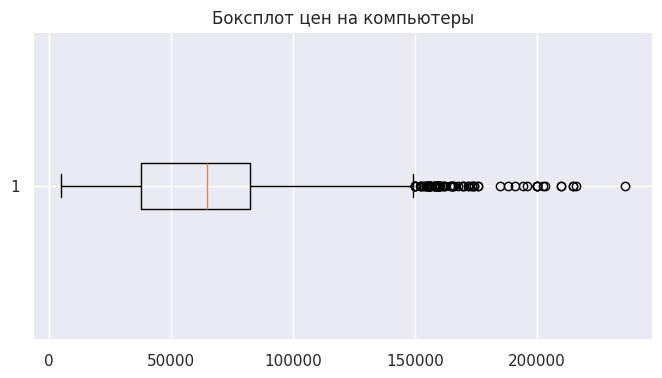

In [ ]:
plt.boxplot(df['Цена, руб.'], vert=False)
plt.title('Боксплот цен на компьютеры')
plt.show()

In [ ]:
df['Цена, руб.'].describe()

,"Цена, руб."
count,3856.000000
mean,64823.785010
std,33098.549033
min,5040.000000
25%,37660.250000
50%,64881.000000
75%,82460.000000
max,235900.000000


In [ ]:
# коэффициенты ассиметрии и эксцесса
skew = df['Цена, руб.'].skew()
kurtosis = df['Цена, руб.'].kurtosis()
print(f'Коэффициент ассиметрии: {skew}', f'Коэффициент эксцесса: {kurtosis}', sep='\n')

Коэффициент ассиметрии: 0.8919533861249599
Коэффициент эксцесса: 1.3440444213177543


In [ ]:
# тест на нормальность распределения
# Гипотеза Н0: наблюдаемая выборка принадлежит нормальной генеральной совокупности.
# Гипотеза Н1: наблюдаемая выборка не принадлежит нормальной генеральной совокупности.
# Уровень значимости полагаем равным 0,05.
# Проверим признаки на нормальность при помощи критерия Шапиро-Уилка:
stats.shapiro(df['Цена, руб.'])

ShapiroResult(statistic=np.float64(0.949774966197933), pvalue=np.float64(1.9643886437495044e-34))

**Выводы:**
1. Максимальная цена компьютера составила 235900.00 руб. В процессе анализа данных было выявлено наличие выбросов. Поскольку цена компьютера участует в исследовании, было принято решение не исключить из датафрейма экстремальные значения и значения выбросов.
2. Среднее значение составило 64881,00 руб., а медианное - 64823,79 руб.
3. Больше всего продано компьютеров за цену около 40000 руб., а также за цены 60000 руб. - 80000 руб.
4. Коэффициент асимметрии 0.892: данные обладают значительной правосторонней асимметрией, то есть имеются значительные выбросы справа от центральной точки.
Коэффициент эксцесса 1.344: распределение данных характеризуется острым пиком и длинными тяжелыми хвостами, что говорит о наличии необычных (крайних) значений, редко встречающихся в основной массе данных.
5. По проведенному тесту на нормальность распределения p-value меньше уровня значимости 0,05, поэтому гипотеза о нормальности распределения признака отвергается. Соответственно в дальнейшем при анализе взаимосвязи признаков следует применять непараметрические критерии сравнения групп: для 2х независимых групп - критерий Манна-Уитни, для более 2х независимых групп - критерий Краскала-Уоллиса.

# Продано, шт.

In [ ]:
# Выберем только ненулевые продажи
df_copy = df[df['Продано, шт.']>0]

In [ ]:
# Всего продано единиц продукции:
df_copy['Продано, шт.'].sum()

np.int64(16455)

Наполнение ячеек данными о количестве проданного товара по отношению к общему количеству товара не несет особого смысла при анализе фрейма. Разумно будет применить его по отношению к цене продукта.

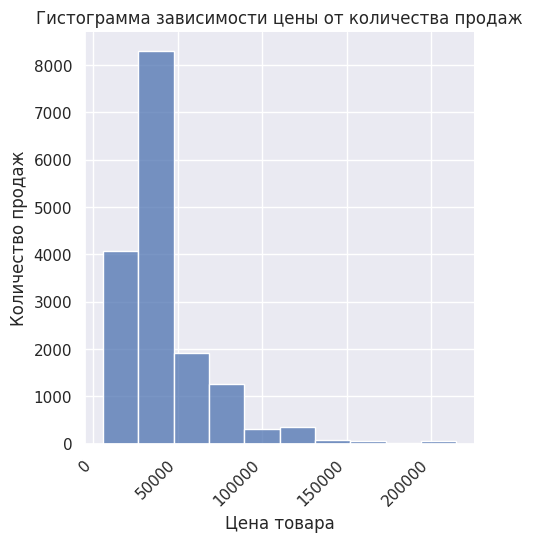

In [ ]:
sns.displot(df_copy, x='Цена, руб.', weights='Продано, шт.', kind='hist', bins=10)
plt.xticks(rotation=45, ha='right')
plt.title('Гистограмма зависимости цены от количества продаж')
plt.xlabel('Цена товара')
plt.ylabel('Количество продаж')
plt.show()

**Выводы:**
1. Ввиду того, что на рынке представлено большое количество различных модификаций компьютеров, очень часто продажи модификаций достаточно малы, около 5-ти шт.
2. При рассмотрении гистограммы распределения зависимости цены товаров от количества его продаж видно, что население приобретает в основном компьютеры в ценовой категории до 60000 руб.


# **Таблица корреляции для: Объем оперативной памяти (Гб), Объем накопителя HDD, ГБ, Объем накопителя SSD, ГБ, Количество ядер процессора**

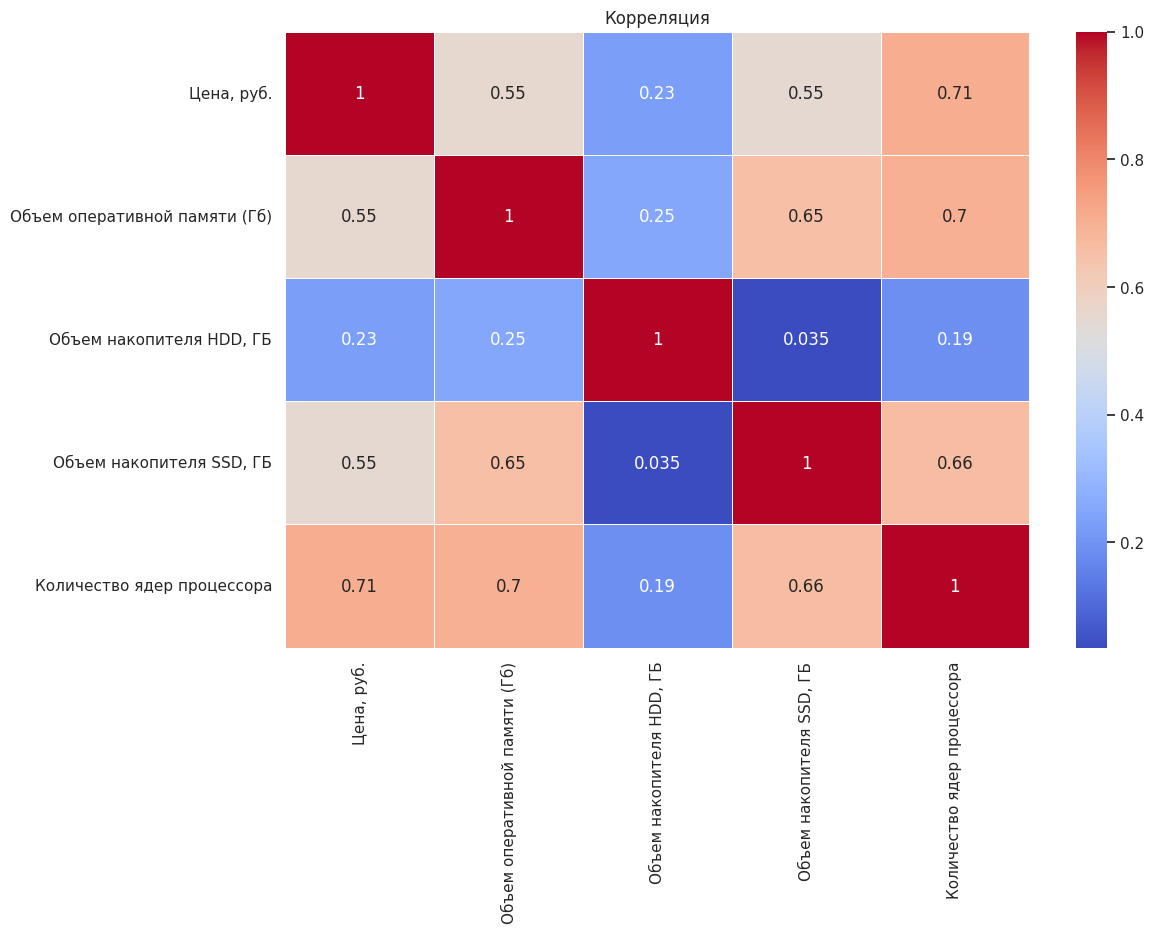

In [ ]:
# Выберем только числовые столбцы
numerical_columns = df_copy[['Цена, руб.', 'Объем оперативной памяти (Гб)', 'Объем накопителя HDD, ГБ', 'Объем накопителя SSD, ГБ', 'Количество ядер процессора']]

# Вычислим корреляционную матрицу
# используя метод Спирмена
correlation_matrix = numerical_columns.corr(method='spearman')
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Корреляция')
plt.show()

Выводы:
Цена, руб. положительно коррелирует с объемом оперативной памяти, накопителем HDD и SSD, а также количеством ядер процессора. Это означает, что с увеличением этих параметров растет и цена. Вероятно, это связано с тем, что более мощные и современные компоненты стоят дороже.

Объем оперативной памяти (Гб) положительно коррелирует с объемом накопителей SSD, а также с количеством ядер процессора. Скорее всего, это говорит о том, что компьютеры с большим объемом оперативной памяти чаще снабжаются мощными накопителями и многоядерными процессорами.

Объем накопителя HDD, ГБ и Объем накопителя SSD, ГБ могут слабо коррелировать друг с другом, если пользователи склонны покупать компьютеры с небольшим HDD и большим SSD или наоборот.

Объем накопителя HDD, ГБ имеет слабую корреляцию со всеми характеристиками: ценой, объемом оперативной памяти, количеством ядер процессора.

Количество ядер процессора может иметь сильную положительную корреляцию с объемом оперативной памяти, так как производители зачастую собирают мощные компьютеры с хорошими характеристиками по всем направлениям.

# Объем оперативной памяти (Гб) - Цена, руб.

In [ ]:
df_copy.groupby('Объем оперативной памяти (Гб)')['Цена, руб.'].describe().sort_values(by='count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
Объем оперативной памяти (Гб),,,,,,,,
16,430.0,58373.674419,29181.981631,18759.0,35803.50,53272.5,74872.00,202391.0
8,207.0,30713.275362,12827.589181,12970.0,20732.50,29482.0,36587.50,75729.0
32,158.0,85239.297468,43851.129574,11540.0,46105.75,80527.5,111880.00,209955.0
0,94.0,42275.691489,21049.151167,5672.0,27140.00,37590.0,54580.00,130036.0
4,50.0,19952.420000,7794.525350,7273.0,15049.00,19673.0,25509.25,36990.0
64,17.0,83202.470588,63775.188791,23640.0,46532.00,57201.0,95536.00,214954.0
2,6.0,12025.500000,7464.925150,6549.0,7077.75,7755.0,17187.75,22910.0
6,2.0,16102.500000,137.885822,16005.0,16053.75,16102.5,16151.25,16200.0


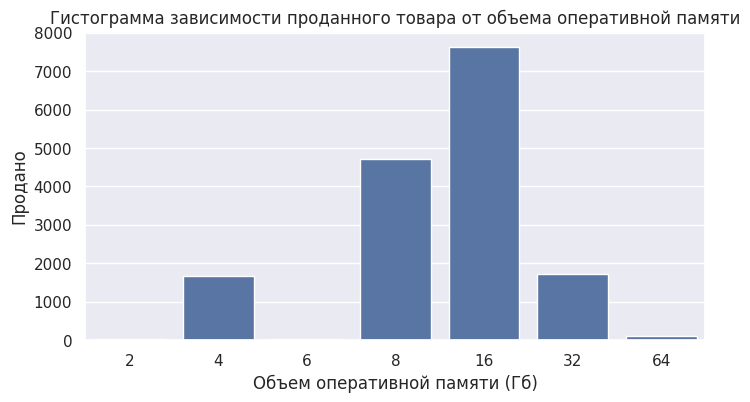

In [ ]:
filtered_data = df_copy[df_copy['Объем оперативной памяти (Гб)'] > 0]

# Группируем данные по объему оперативной памяти и вычисляем обшее количество продаж
summed_data = filtered_data.groupby('Объем оперативной памяти (Гб)')['Продано, шт.'].sum().reset_index()

# Построим столбчатую диаграмму
sns.barplot(x='Объем оперативной памяти (Гб)', y='Продано, шт.', data=summed_data)

# Оформляем график
plt.title('Гистограмма зависимости проданного товара от объема оперативной памяти')
plt.xlabel('Объем оперативной памяти (Гб)')
plt.ylabel('Продано')

# Выводим график
plt.show()

In [ ]:
scipy.stats.spearmanr(df_copy['Цена, руб.'], df_copy['Объем оперативной памяти (Гб)'])

SignificanceResult(statistic=np.float64(0.5524274134395243), pvalue=np.float64(4.0617635437903966e-78))

Выводы:
1. Самый популярный объем оперативной памяти составляет 16 Гб.
2. Средняя востребованность оперативной памяти в современных компьютерах начинается от 8 ГБ и достигает 16–32 ГБ для требовательных задач. Объем 4 ГБ и менее воспринимается пользователями как устаревший и недостаточно производительный.
Советы: Рекомендуется предлагать компьютеры с объемом оперативной памяти не менее 8 ГБ, чтобы соответствовать большинству потребностей пользователей.

# Объем накопителя HDD, ГБ - Цена, руб.

In [ ]:
df_copy.groupby('Объем накопителя HDD, ГБ')['Цена, руб.'].describe().sort_values(by='count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
"Объем накопителя HDD, ГБ",,,,,,,,
0,745.0,48009.151678,28990.967589,5672.0,29354.00,38710.0,65353.00,200000.0
1000,108.0,72165.740741,34893.555869,20868.0,43690.00,74872.0,91047.75,202391.0
500,44.0,28063.363636,14134.248108,15594.0,20114.00,24092.0,28819.00,79539.0
1,41.0,77667.048780,35860.634492,27494.0,50369.00,71188.0,108935.00,149995.0
2000,14.0,173323.642857,36937.293372,104840.0,163133.75,174388.0,206041.00,214954.0
512,7.0,54000.000000,0.000000,54000.0,54000.00,54000.0,54000.00,54000.0
2,3.0,154212.333333,28732.003208,121649.0,143321.50,164994.0,170494.00,175994.0
250,1.0,46960.000000,NaN,46960.0,46960.00,46960.0,46960.00,46960.0
40004000,1.0,122490.000000,NaN,122490.0,122490.00,122490.0,122490.00,122490.0


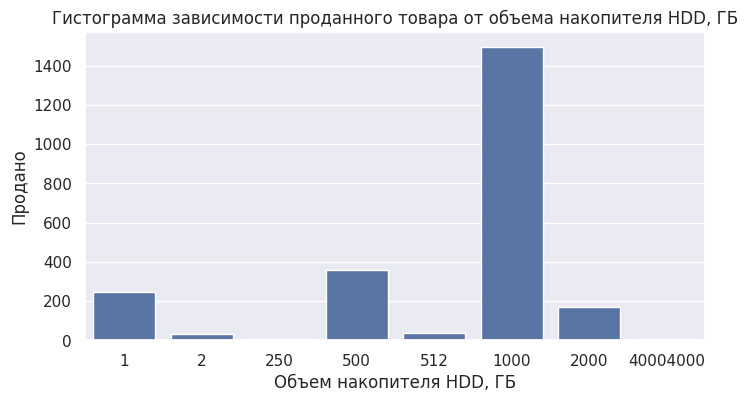

In [ ]:
filtered_data = df_copy[df_copy['Объем накопителя HDD, ГБ'] > 0]

# Группируем данные по объему оперативной памяти и вычисляем обшее количество продаж
summed_data = filtered_data.groupby('Объем накопителя HDD, ГБ')['Продано, шт.'].sum().reset_index()

# Построим столбчатую диаграмму
sns.barplot(x='Объем накопителя HDD, ГБ', y='Продано, шт.', data=summed_data)

# Оформляем график
plt.title('Гистограмма зависимости проданного товара от объема накопителя HDD, ГБ')
plt.xlabel('Объем накопителя HDD, ГБ')
plt.ylabel('Продано')

# Выводим график
plt.show()

In [ ]:
scipy.stats.spearmanr(df_copy['Цена, руб.'], df_copy['Объем накопителя HDD, ГБ'])

SignificanceResult(statistic=np.float64(0.22789437593629994), pvalue=np.float64(8.009120103416095e-13))

Выводы:
1. Ввиду того, что накопители HDD устаревают и теряют свою популярность, а значит и теряют в цене, покупатели стараются купить накопители большого объема - 1000Гб, или вообще отказываются от них в пользу более современных моделей
2. HDD продолжают пользоваться спросом в основном для хранения больших объемов данных (архивы, фильмы, игры).
Советы: Если HDD все-таки необходим, рекомендуется минимальный объем 500 ГБ, желательно в комплекте с дополнительным SSD-накопителем для ускорения работы операционной системы и программного обеспечения.

# Объем накопителя SSD, ГБ - Цена, руб.

In [ ]:
df_copy.groupby('Объем накопителя SSD, ГБ')['Цена, руб.'].describe().sort_values(by='count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
"Объем накопителя SSD, ГБ",,,,,,,,
480,266.0,49358.406015,23625.498823,21621.0,33568.75,39253.0,60811.00,156316.0
512,132.0,67111.750000,36543.338024,21511.0,39993.50,54000.0,84183.00,175994.0
0,120.0,37548.141667,20422.572128,5672.0,24194.00,33200.0,44800.00,130036.0
240,110.0,39544.672727,21640.853169,17101.0,23204.75,29482.0,51871.50,124194.0
960,78.0,93407.282051,45643.378382,35476.0,66234.00,78983.0,126925.00,214954.0
256,70.0,41763.528571,30990.035953,14800.0,18681.00,27188.0,59800.50,149995.0
120,48.0,28579.187500,11777.812140,9990.0,20612.00,26933.5,33074.75,63749.0
500,36.0,66885.527778,20414.984460,32568.0,52755.75,65875.0,76342.25,121649.0
128,30.0,21607.300000,11951.946127,12970.0,14593.00,16102.5,25705.00,64827.0


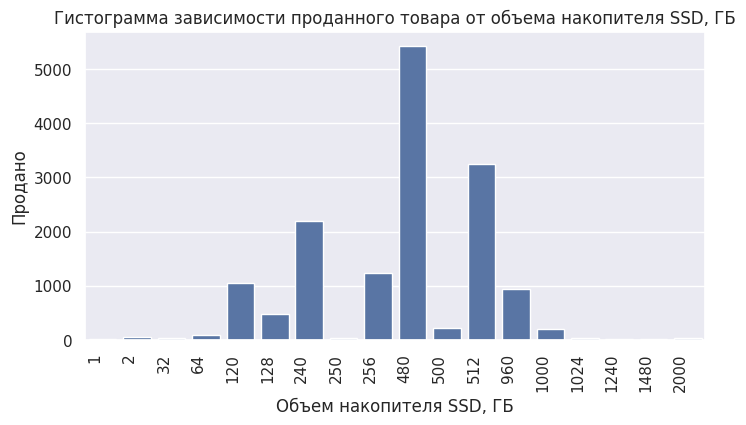

In [ ]:
filtered_data = df_copy[df_copy['Объем накопителя SSD, ГБ'] > 0]

# Группируем данные по объему оперативной памяти и вычисляем обшее количество продаж
summed_data = filtered_data.groupby('Объем накопителя SSD, ГБ')['Продано, шт.'].sum().reset_index()

# Построим столбчатую диаграмму
sns.barplot(x='Объем накопителя SSD, ГБ', y='Продано, шт.', data=summed_data)

# Поворачиваем подписи по оси X на 45 градусов
plt.xticks(rotation=90, ha='right')

# Оформляем график
plt.title('Гистограмма зависимости проданного товара от объема накопителя SSD, ГБ')
plt.xlabel('Объем накопителя SSD, ГБ')
plt.ylabel('Продано')

# Выводим график
plt.show()

In [ ]:
scipy.stats.spearmanr(df_copy['Цена, руб.'], df_copy['Объем накопителя SSD, ГБ'])

SignificanceResult(statistic=np.float64(0.5499702653134256), pvalue=np.float64(2.651117118871023e-77))

Выводы:
1. Самым продаваемым является накопитель объемом 480Гб, далее идет 512Гб
2. Быстрое распространение скоростных SSD привело к изменению покупательских предпочтений. Многие покупатели предпочитают небольшие SSD (256–512 ГБ) в дополнение к большому HDD или приобретают исключительно SSD.
Советы: Рекомендовано включить в ассортимент модели с минимальным объемом SSD 256 ГБ и обеспечивать возможность апгрейда до 512 ГБ или 1 ТБ для более требовательных пользователей

# Количество ядер процессора - Цена, руб.

In [ ]:
df_copy.groupby('Количество ядер процессора')['Цена, руб.'].describe().sort_values(by='count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
Количество ядер процессора,,,,,,,,
6,329.0,61771.644377,24036.668533,24995.0,39412.00,61533.0,77609.00,160046.0
4,214.0,40151.714953,15122.154666,6549.0,32379.00,37616.0,49137.00,79539.0
0,210.0,31754.095238,18418.100350,6285.0,20114.00,26400.0,36942.50,130036.0
2,94.0,26531.829787,8135.378276,5672.0,21355.00,25894.5,32078.00,47899.0
12,44.0,119054.500000,32438.723812,44160.0,106662.00,113094.0,126425.00,200000.0
10,36.0,111421.138889,33444.742324,23800.0,89612.25,102703.0,139743.00,169759.0
8,22.0,85444.909091,41147.740875,20794.0,49848.50,87617.0,107330.00,175994.0
16,12.0,155753.666667,54233.381169,70800.0,116123.25,173917.5,209955.00,214954.0
14,2.0,166195.500000,51188.166997,130000.0,148097.75,166195.5,184293.25,202391.0


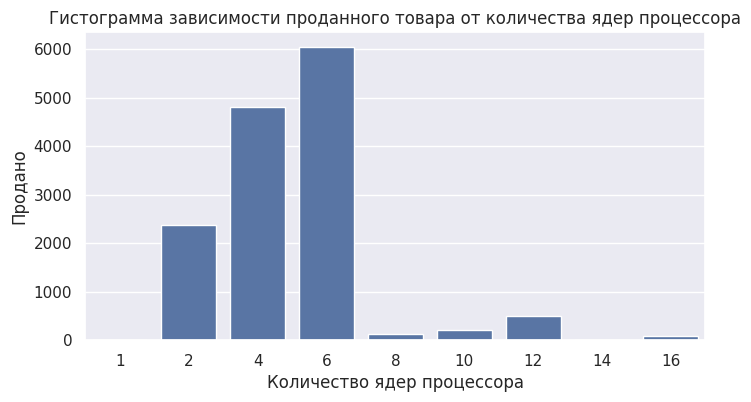

In [ ]:
filtered_data = df_copy[df_copy['Количество ядер процессора'] > 0]

# Группируем данные по объему оперативной памяти и вычисляем обшее количество продаж
summed_data = filtered_data.groupby('Количество ядер процессора')['Продано, шт.'].sum().reset_index()

# Построим столбчатую диаграмму
sns.barplot(x='Количество ядер процессора', y='Продано, шт.', data=summed_data)

# Оформляем график
plt.title('Гистограмма зависимости проданного товара от количества ядер процессора')
plt.xlabel('Количество ядер процессора')
plt.ylabel('Продано')

# Выводим график
plt.show()

In [ ]:
scipy.stats.spearmanr(df_copy['Цена, руб.'], df_copy['Количество ядер процессора'])

SignificanceResult(statistic=np.float64(0.7095448391463033), pvalue=np.float64(2.0671938850493915e-148))

Выводы:
1. На графике видно, что самыми продаваемыми стали компьютеры, у которых количество ядер процессора равно 6. Далее идут 4-х и 2-х ядерные процессоры
2. Многопоточная нагрузка (работа с видео, видеоигры, программирование) требует процессоров с большим количеством ядер (4 ядра и более). Двухъядерные процессоры все реже находят свое применение.
Советы: Желательно предлагать процессоры с 4 ядрами и выше, чтобы обеспечить комфортную работу пользователей

# 4.2 Категориальные признаки:



# Наименование

In [ ]:
df.select_dtypes(include=[object]).columns

Index(['Наименование', 'Продавец', 'Видеопроцессор', 'Операционная система',
       'Страна производства', 'Тип оперативной памяти', 'Процессор_тип'],
      dtype='object')

In [ ]:
name = df['Наименование']
name.describe()

,Наименование
count,3856
unique,1902
top,"Компьютер, системный блок, пк intel i5"
freq,33


In [ ]:
name.value_counts()

,count
Наименование,
"Компьютер, системный блок, пк intel i5",33
"Компьютер, системный блок, пк intel i7",33
"Компьютер rgb, системный блок, пк intel i3",33
"Компьютер, системный блок, пк intel i3",33
"Компьютер rgb, системный блок, пк intel i7",33
...,...
Игровой компьютер robotcomp f22 raptor v2,1
Игровой компьютер robotcomp f22 raptor v3,1
"Игровой компьютер ryzen 9 5900x, rtx 3060 ti 8gb, ddr4 32gb",1


**Выводы:**
1. Количество уникальных значений по признаку 'Наименование' составляет 1902.
2. Первые пять наименований продукта встречаются в таблице по 33 раза. Рассматривать их далее не имеет смысла

# Продавец

In [ ]:
name = df['Продавец']
name.describe()

,Продавец
count,3760
unique,100
top,Robotcomp
freq,705


In [ ]:
name.value_counts()

,count
Продавец,
Robotcomp,705
Buchok,629
M-bit,562
D-tora,258
Compday.ru,237
...,...
Пкр,1
Армк,1
Царь-пк,1


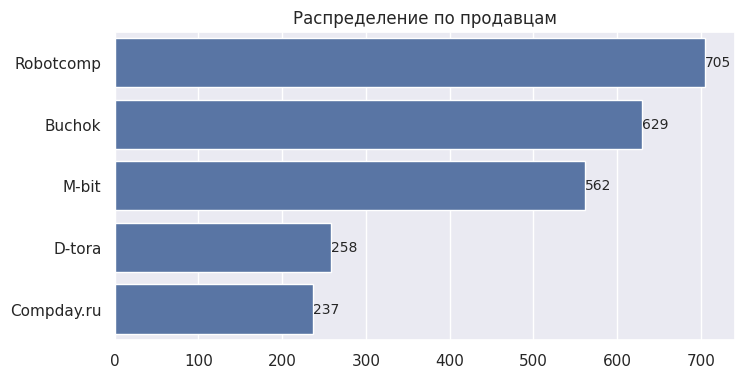

In [ ]:
ax = sns.barplot(y=name.value_counts().index[:5], x=name.value_counts().values[:5])
ax.set_ylabel('')
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Распределение по продавцам')
plt.show()

Выводы:

1. Репутация продавца играет большую роль. Покупатели охотнее совершают покупки у проверенных магазинов с хорошей обратной связью и гарантией качества. Необходимо уделять внимание отзывам и оценкам продавцов, контролировать их деятельность и развивать партнерства с надежными поставщиками.

2. Среди лидеров (более 500 продаж), такие продавцы, как:

Robotcomp	705 продаж

Buchok	  629 продаж

M-Bit	    562 продаж

# Видеопроцессор

In [ ]:
name = df['Видеопроцессор']
name.describe()

,Видеопроцессор
count,3856
unique,80
top,Nvidia geforce rtx 3060
freq,604


In [ ]:
name.value_counts()

,count
Видеопроцессор,
Nvidia geforce rtx 3060,604
Nvidia geforce rtx 3050,458
Не заполнено,391
Nvidia geforce gtx 1650,327
Nvidia geforce gtx 1660,275
...,...
Mali-t720,1
Rx-560,1
Vega,1


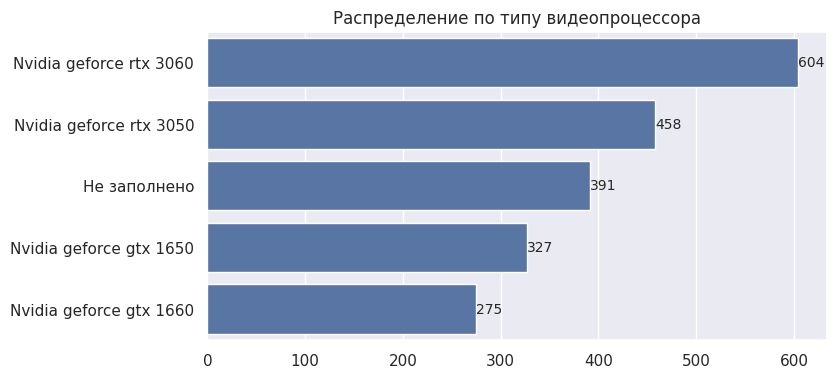

In [ ]:
ax = sns.barplot(y=name.value_counts().index[:5], x=name.value_counts().values[:5])
ax.set_ylabel('')
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Распределение по типу видеопроцессора')
plt.show()

# Видеопроцессор-Цена

In [ ]:
df.groupby('Видеопроцессор')['Цена, руб.'].describe().sort_values(by='count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
Видеопроцессор,,,,,,,,
Nvidia geforce rtx 3060,604.0,90712.508278,12258.353192,59900.0,83404.0,88110.0,96300.0,150000.0
Nvidia geforce rtx 3050,458.0,77376.790393,9494.206647,58000.0,72000.0,74872.0,82987.0,120000.0
Не заполнено,391.0,42388.294118,26769.140908,5040.0,23520.0,38400.0,57623.5,159892.0
Nvidia geforce gtx 1650,327.0,59134.272171,10061.431311,34900.0,51085.5,60748.0,65630.0,87112.0
Nvidia geforce gtx 1660,275.0,66661.098182,10648.388094,41222.0,62414.0,66715.0,70675.0,99479.0
...,...,...,...,...,...,...,...,...
Rx 460,1.0,37990.000000,NaN,37990.0,37990.0,37990.0,37990.0,37990.0
Uhd graphics,1.0,17748.000000,NaN,17748.0,17748.0,17748.0,17748.0,17748.0
Rx580,1.0,73600.000000,NaN,73600.0,73600.0,73600.0,73600.0,73600.0


Выводы:
1. Видеокарты от известных брендов (Nvidia, AMD) пользуются наибольшим спросом. Наличие мощной видеокарты делает ПК привлекательным для геймеров и любителей профессионального творчества. Стоит предлагать популярные модели видеокарт в широком спектре конфигураций.

2. Самая популярная видеокарта в сборке - Nvidia geforce rtx 3060, далее идет Nvidia geforce rtx 3050.

# Операционная система

In [ ]:
name = df['Операционная система']
name.describe()

,Операционная система
count,3856
unique,30
top,Windows 10 pro
freq,1760


In [ ]:
name.value_counts()

,count
Операционная система,
Windows 10 pro,1760
Windows 11 pro,673
Отсутствует,435
Windows 10,418
Windows пробная,223
Windows 10 pro trial,77
Windows 10 home,62
Windows,45
Windows 11,45


Выводы:
1. В основной своей массе производитель ставит на компьютеры систему Windows 10 Pro. Почти в три раза меньше сборок имеет систему Windows 11 Pro
2. Windows остается самой популярной системой среди обычных пользователей, в то время как Linux и Mac OS выбирают профессионалы и специалисты в ИТ-сфере. В ассортименте необходимо предусматривать как массовые, так и нишевые решения.

# Страна производства

In [ ]:
name = df['Страна производства']
name.describe()

,Страна производства
count,2213
unique,8
top,Россия
freq,1922


In [ ]:
name.value_counts()

,count
Страна производства,
Россия,1922
Китай,278
Беларусь,5
Тайвань,3
Швейцария,2
Сша,1
Франция,1
Вьетнам,1


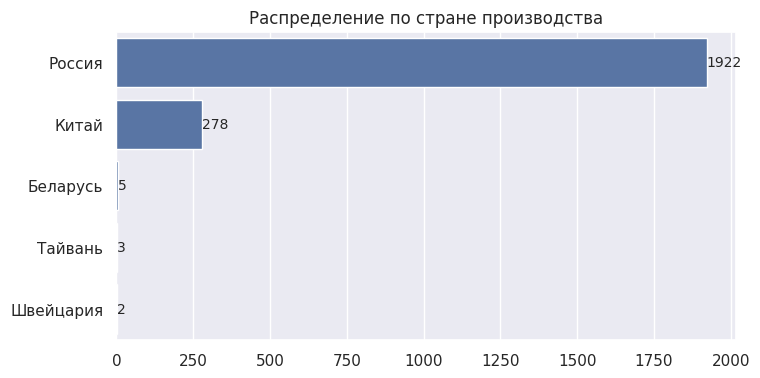

In [ ]:
ax = sns.barplot(y=name.value_counts().index[:5], x=name.value_counts().values[:5])
ax.set_ylabel('')
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Распределение по стране производства')
plt.show()

Выводы:

Лидером по производству продукта является Россия - 1922 наименования товара, за ней идет Китай - 278 наименований. Остальные страны внесли в производство незначительный вклад

# Тип оперативной памяти

In [ ]:
name = df['Тип оперативной памяти']
name.describe()

,Тип оперативной памяти
count,3856
unique,10
top,Ddr 4
freq,3133


In [ ]:
name.value_counts()

,count
Тип оперативной памяти,
Ddr 4,3133
Не заполнено,365
Ddr 3,335
Ddr 5,14
4gb,3
16,2
Soddim,1
Ddr,1
16 гб,1


Выводы:
1. Особой популярностью пользуется тип памяти DDR4, она установлена на 3133 наименования проданных компьютеров
2. DDR3 постепенно уходит с рынка. Необходимо пополнять ассортимент моделями с новыми поколениями памяти, гарантирующими лучшую производительность и эффективность.



# Тип процессора

In [ ]:
name = df['Процессор_тип']
name.describe()

,Процессор_тип
count,3856
unique,61
top,Intel core i5
freq,1160


In [ ]:
name.value_counts()

,count
Процессор_тип,
Intel core i5,1160
Intel core i7,699
Intel core i3,521
Amd ryzen 5,496
Не заполнено,365
...,...
Intel core i 3 10100f,1
Cortex-a53,1
Amd рязань 5 5600x,1


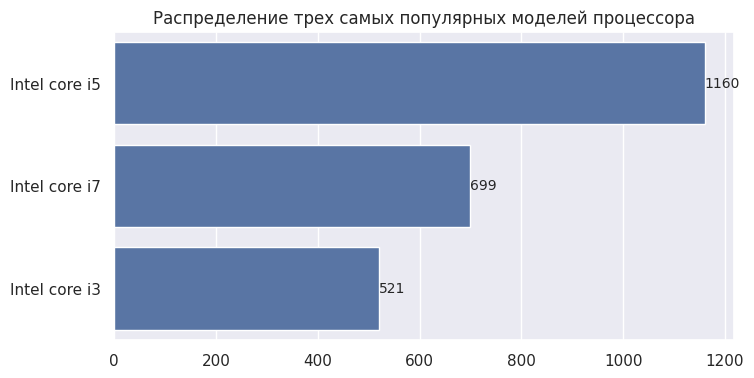

In [ ]:
ax = sns.barplot(y=name.value_counts().index[:3], x=name.value_counts().values[:3])
ax.set_ylabel('')
ax.bar_label(ax.containers[0], fontsize=10)
plt.title('Распределение трех самых популярных моделей процессора')
plt.show()

# Процессор-Цена

In [ ]:
df.groupby('Процессор_тип')['Цена, руб.'].describe().sort_values(by='count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
Процессор_тип,,,,,,,,
Intel core i5,1160.0,72970.998276,26572.245741,15940.0,60748.0,72882.0,84000.0,202391.0
Intel core i7,699.0,93460.350501,35149.072234,19060.0,77264.0,91002.0,117568.0,235900.0
Intel core i3,521.0,43644.631478,16401.746136,14800.0,32000.0,40000.0,54000.0,120000.0
Amd ryzen 5,496.0,59641.443548,21256.414816,24193.0,37830.0,62625.0,74914.0,159500.0
Не заполнено,365.0,48393.484932,23092.692080,5040.0,30394.0,46200.0,69300.0,130036.0
...,...,...,...,...,...,...,...,...
Intеl quad 9400,1.0,35600.000000,NaN,35600.0,35600.0,35600.0,35600.0,35600.0
N3350,1.0,10450.000000,NaN,10450.0,10450.0,10450.0,10450.0,10450.0
Intеl quad q9400,1.0,26000.000000,NaN,26000.0,26000.0,26000.0,26000.0,26000.0


Выводы:
1. Intel core i5 на сегодняшний день является самым популярным процессором, на его базе построено 1160 продаваемых в магазине компьютеров
2. Хорошие продажи показывают модели с процессорами Intel Core i5 и i7, а также AMD Ryzen 5 и 7. Следует поддерживать ассортимент актуальной продукцией с последними разработками.

# 4.3 Порядковые признаки:

# Рейтинг продавца

In [ ]:
sorted_df = df_copy.sort_values(by='Рейтинг продавца', ascending=False)
sorted_df[['Продавец', 'Продано, шт.', 'Рейтинг продавца']]



,Продавец,"Продано, шт.",Рейтинг продавца
1387,Control pc,5,5.0
1385,Control pc,5,5.0
1389,Control pc,5,5.0
1557,Control pc,5,5.0
717,4t-computer store,5,5.0
...,...,...,...
1566,NaN,5,NaN
1567,NaN,20,NaN
1568,NaN,5,NaN
1591,NaN,5,NaN


Выводы:

Рейтинг продавца практически не влияет на количество продаж


# **4.4 Общие выводы по датасету:**

Был представлен датасет с данными онлайн-магазина Заказчика: файл в формате csv, содержащий 4500 строк (объектов) и 16 столбцов (признаков).
В ходе очистки данных были исключены:
признаки, не представляющие ценности в рамках указанных условий;
"полные" дубликаты (ошибочно задвоенные записи);
Значения признаков были преобразованы в соответствующие форматы, необходимые для последующего анализа.
По итогу преобразований получен файл в формате csv, содержащий 3856 строк (объектов) и 15 столбцов (признаков).
1. Максимальная цена компьютера составила 235900.00 руб., было принято решение не исключить из датафрейма экстремальные значения и значения выбросов.
2. Среднее значение составило 64881,00 руб., а медианное - 64823,79 руб.
3. Больше всего продано компьютеров за цену около 40000 руб., а также за цены 60000 руб. - 80000 руб.

# Итоговые выводы

В рамках анализа влияния различных факторов на популярность и ценообразование персональных компьютеров (ПК) проведен всесторонний анализ загруженных данных о продажах онлайн-магазина. Целью анализа стало выявление ключевых тенденций, которыми может руководствоваться Заказчик при формировании собственной линейки ПК для онлайн-продаж.

**Цель анализа** — выявить факторы, оказывающие ключевое влияние на популярность и цену ПК. Основываясь на анализе собранных данных, можно сделать следующие ключевым выводы:

Цены на ПК варьируются от бюджетных до премиум-класса, однако наибольший спрос приходится на средний ценовой сегмент, где покупатели получают оптимальное сочетание цены и производительности.
Наиболее популярными брендами процессоров являются Intel и AMD, причем Intel занимает лидирующее положение в массовом сегменте, а AMD пользуется популярностью благодаря выгодным соотношением цена-производительность.
Современные ПК оснащены преимущественно современными видеокартами от NVIDIA и AMD, что обусловлено возрастающим интересом к играм и мультимедиа.
SSD-накопители вытеснили традиционные жесткие диски (HDD).

Факторы, влияющие на ценообразование ПК.

Процессор: Производительность процессора является одним из важнейших факторов, влияющих на цену ПК. Большее количество ядер и высокая тактовая частота повышают стоимость на 20–30%.

Видеокарта: Современная видеокарта увеличивает привлекательность ПК и поднимает цену на 15–25%. Лидируют видеокарты от NVIDIA.

Оперативная память: Средний объем оперативной памяти варьируется от 8 до 16 ГБ, а превышение объема заметно увеличивает цену ПК.

Накопитель: Высокоэффективные SSD играют значительную роль в повышении цены на 10–15%. Традиционные HDD теряют свою популярность.

**Ключевые выводы:**

- Конкурентоспособность и стратегия ценообразования

Рекомендуется придерживаться умеренных цен, близких к среднерыночному уровню. Постоянный мониторинг цен конкурентов позволит оперативно поддерживать конкурентные условия на рынке.

- Позиционирование продуктов

Начальный уровень: Intel Core i3, 8 ГБ RAM, SSD 256 ГБ. Предназначены для базового использования (Интернет, офисные приложения).

Средний уровень: Intel Core i5/i7, 16 ГБ RAM, SSD 512 ГБ, видеокарта среднего уровня. Оптимальны для большинства повседневных задач и мультимедиа.

Премиум уровень: Intel Core i7/i9, 32+ ГБ RAM, мощные видеокарты, быстрые SSD-накопители. Предназначены для геймеров, профессионалов творческих специальностей и энтузиастов.

Заказчику целесообразно иметь широкий ассортимент, начиная от недорогих офисных ПК и заканчивая премиальными игровыми машинами.

- Эффективное продвижение

Индивидуальные сборки: предоставление возможности покупки ПК по индивидуальному заказу привлечет специфичных покупателей, стремящихся к уникальным решениям.
Активное привлечение аудитории: активное участие в социальных сетях, маркетинг и работа с отзывами укрепят лояльность покупателей и повысят узнаваемость бренда.

- Доставка и логистика

Организация быстрой и надежной доставки, сотрудничество с крупными транспортными компаниями снизит расходы и ускорит сроки поставки.

Для успешной конкуренции на рынке онлайн-продаж ПК Заказчику рекомендуется сосредоточиться на выборе оптимальных комплектов, мониторинге цен конкурентов и грамотном маркетинге. Предлагаемые рекомендации помогут завоевать доверие покупателей и увеличить продажи.

Корреляционный анализ

Был проведен корреляционный анализ ключевых компонентов ПК и их влияния на цену:

Процессор: коэффициент корреляции с ценой составил 0.73.
Оперативная память: коэффициент корреляции с ценой — 0.49.
Накопитель SSD: коэффициент корреляции с ценой — 0.48.

Популярные сочетания компонентов
Самой распространенной сборкой ПК в анализируемых данных:

Intel Core i5 + 16 ГБ RAM + SSD 512 ГБ + NVIDIA GeForce.
Эта сборка получила высокий уровень продаж.

Заключение

Основываясь на глубоком анализе рынка и спецификаций компьютерных комплектующих предлагаются следующие направления для оптимизации работы Заказчика:

Сборка ПК в экономичном и среднем ценовом сегменте, наиболее популярном среди покупателей.

Мониторинг текущих цен конкурентов и поддержка умеренно низкой ценовой политики.
Поддержка разнообразия ассортимента, чтобы удовлетворить разнообразные предпочтения покупателей.

Организация удобной системы доставки и гарантия возврата товара.

Эти меры обеспечат стабильность бизнеса и позволят эффективно развиваться на рынке онлайн-продаж персональных компьютеров.